# Week 4 - classification



## Agenda

1. Logistic regression.
2. Various metrics for evaluation of classification models.
3. Imbalanced data and how to deal with it.
4. Why we need training, validation and test sets.
5. Useful SciKit Learn tools - `Pipeline` and `ColumnTransformer`.
6. Maybe - k-Nearest-Neighbor.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings

import random
import numpy as np

random.seed(42)
np.random.seed(42)

warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")


In [3]:
# read ISLP default data
df = pd.read_csv(
    "https://raw.githubusercontent.com/intro-stat-learning/ISLP/main/ISLP/data/Default.csv"
)

In [4]:
def plot_decision_boundary(
    x1, x2, y, model, thresholds=[0.5], figsize=(7, 7), ax=None, title=None
):
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=figsize)

    x1_min, x1_max = x1.min(), x1.max()
    x2_min, x2_max = x2.min(), x2.max()
    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, 1_000), np.linspace(x2_min, x2_max, 1_000)
    )

    mesh_df = pd.DataFrame({x1.name: xx.ravel(), x2.name: yy.ravel()})

    Z = model.predict_proba(mesh_df)[:, 1]
    Z = Z.reshape(xx.shape)

    ax.contour(xx, yy, Z, levels=thresholds, cmap="Greys", vmin=0, vmax=0.6)

    sns.scatterplot(x=x1, y=x2, hue=y, alpha=0.5, edgecolor="white", linewidth=1, ax=ax)

    if title:
        ax.set_title(title)

## Analysis and cleaning

### Looking at data

In [5]:
df.sample(10)

,default,student,balance,income
6252,No,No,1435.662933,31507.089277
4684,No,No,771.789347,42139.070269
1731,No,No,0.000000,21809.218509
4742,No,No,113.571264,32803.832648
4521,No,No,1358.132472,49903.597081
6340,No,No,1302.553499,32235.052450
576,Yes,No,1763.579088,46227.074542
5202,No,No,857.329142,25742.173767
6363,No,No,1366.725774,35425.512077
439,Yes,Yes,1118.701039,21848.442900


In [6]:
df.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


There's one more thing we should always check when dealing with classification problems - how imbalanced are our classes? Perfectly balanced classes (that is, each class is 50% of the dataset) don't exist in the real world, and most problems actually have quite severe imbalance.

In [8]:
df.value_counts("default")

default
No     9667
Yes     333
Name: count, dtype: int64

Only about 3.3 % of all observations in the dataset have defaulted. This will be a problem that we'll have to get back to later.

### Transforming

The dataset is quite clean. The only transformation I want to apply is converting the `student` and `default` columns into binary 0/1 instead of Yes/No.


In [9]:
value_map = {"Yes": 1, "No": 0}
df["student"] = df["student"].map(value_map)
df["default"] = df["default"].map(value_map)

### Plotting

Let's visually investigate the relationship between the target variable `default` and the predictors.


<Axes: xlabel='balance', ylabel='Density'>

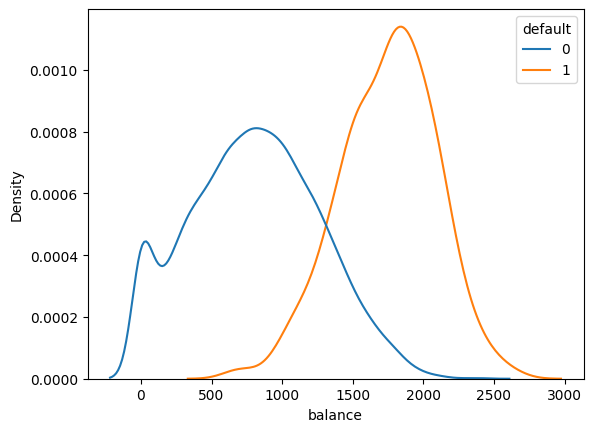

In [10]:
sns.kdeplot(data=df, x="balance", hue="default", common_norm=False)

<Axes: xlabel='income', ylabel='Density'>

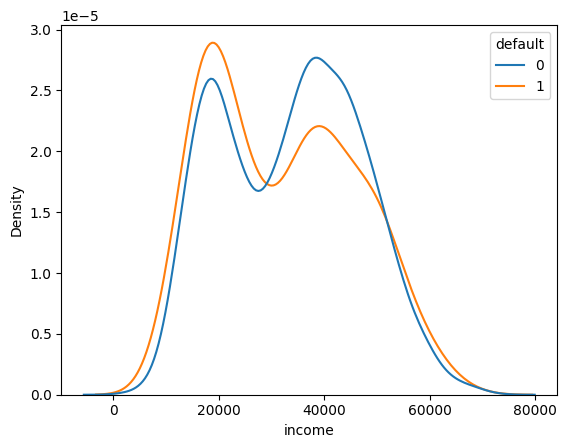

In [11]:
sns.kdeplot(data=df, x="income", hue="default", common_norm=False)

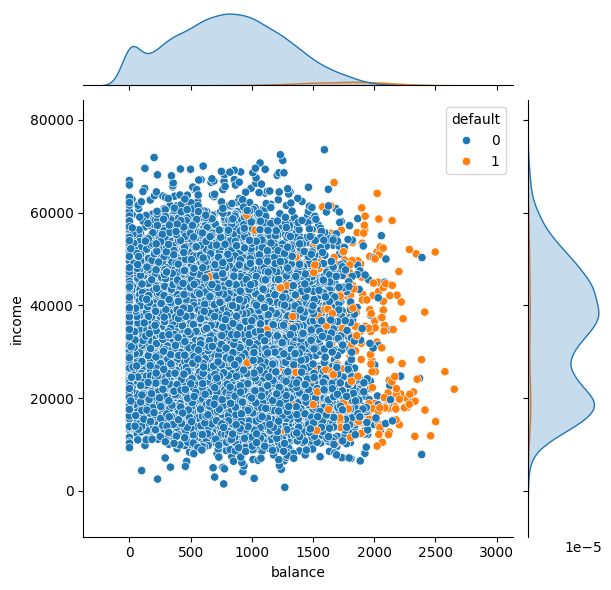

In [ ]:
sns.jointplot(data=df, x="balance", y="income", hue="default")

The plot is quite crowded, and you can barely see any values that have default=1, because the default=0 values overwhelm it.

Let's improve this by using a two-dimensional KDE plot. For the KDE plot we can use common_norm = False to set each group's areas under the curve to be 1. This basically says "show me how the data is distributed ignoring the size difference between groups".


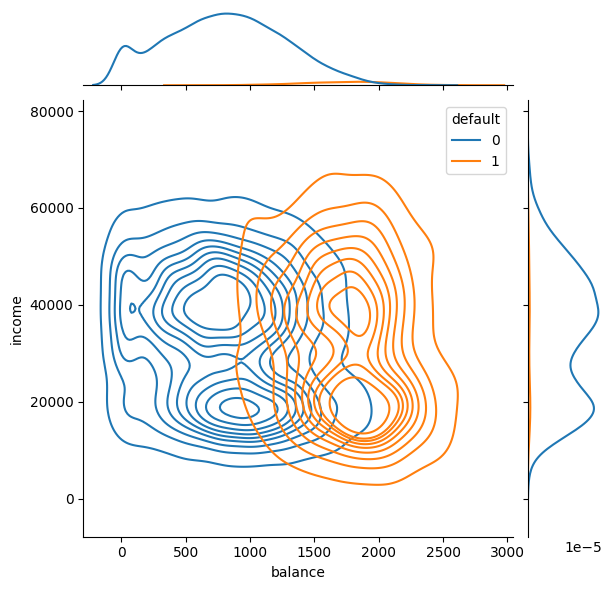

In [13]:
sns.jointplot(
    data=df,
    x="balance",
    y="income",
    hue="default",
    kind="kde",
    common_norm=False,
    # marginal_kws={"common_norm": False},
)

A way better plot!


In [14]:
df.groupby("student")["default"].mean()

student
0    0.029195
1    0.043139
Name: default, dtype: float64

## Modelling


In [15]:
from sklearn.model_selection import train_test_split


We will now split the dataset into train, validation and test sets. You are already familiar with training and validation datasets - the training set is for training the model, while the validation set is for checking how different models perform on unseen data.

The test set is for reporting the performance of the final model. We only make predictions on the test set using the final model that we chose based on how it performs on the validation set.


In [16]:
# First split into train and test (80/20)
df_train, df_test = train_test_split(df, test_size=0.2)

# Then split off a validation set from the training set (75/25, which is 60/20 of original)
df_train, df_val = train_test_split(df_train, test_size=0.25)

What are these three datasets for? 
- The *training* set is for fitting our models. When we call .fit(), we pass the training set as an argument (and only the training set).
- The *validation* set is for choosing the best model in terms of the algorithm and its *hyperparameters*. 
- The *test* set is for reporting the performance of the final model. During any modelling, we should only do predict on our test data once, and that should be the last thing that we do. This is to avoid overstating how good our model is.


In [17]:
target = "default"
y_train = df_train[target]
X_train_bal = df_train["balance"]


### Simple Logistic Regression

When we fit logistic regression models, our goal is to find how probability of the target variable changes as a function of a predictor. In this case - how does probability of `default` change as a function of `balance`.


<Axes: xlabel='balance', ylabel='default'>

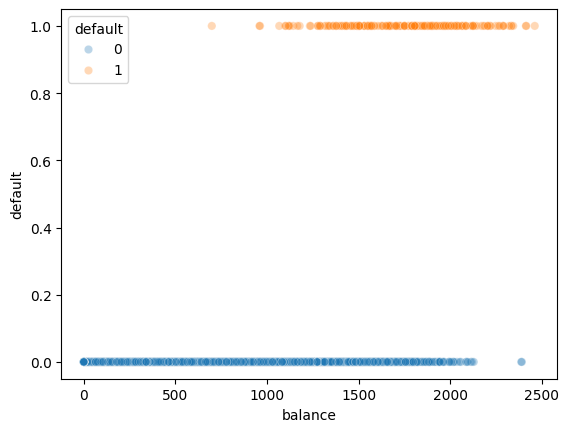

In [18]:
sns.scatterplot(
    data=df_train,
    x="balance",
    y="default",
    hue="default",
    alpha=0.3
)


Logistic regression has the following functional form:

$$
P(x) = \frac{1}{1 + e^{-(\beta_1 + \beta_2 x)}}
$$



In [19]:
def logistic_function(x, b1, b2):
    return 1 / (1 + np.e**(-(b1 + b2*x)))


In [20]:
def model(x):
    b1, b2 = -15, 0.009
    return logistic_function(x, b1, b2)
model(1000)

0.002472623156634775

In [21]:
y_pred = model(X_train_bal)

<Axes: xlabel='balance', ylabel='default'>

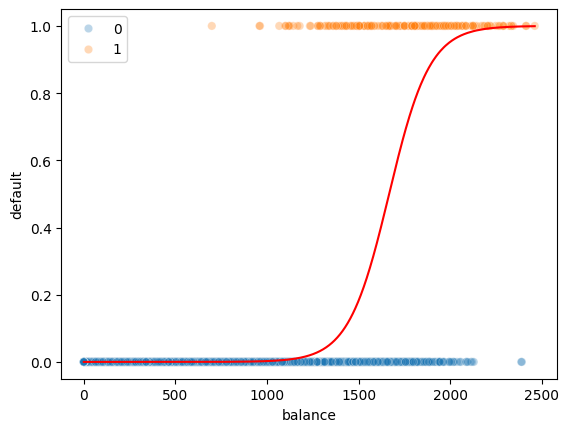

In [22]:
ax = sns.scatterplot(
    data=df_train,
    x="balance",
    y="default",
    hue="default",
    alpha=0.3
)
sns.lineplot(x=X_train_bal, y=y_pred, color="red", ax=ax)


The loss function for logistic regression is called logarithmic loss or log loss for short. To build intuition for it, it is instructive to think about what kind of loss function would you build if it were up to you. You want two things from the loss function:
- You want the model to be penalized for being wrong.
- You want the model to be penalized a lot for being very wrong (non-linearly)

Log loss achieves these goals and it goes as follows:
* if true value = 0: loss = `-log(1-p)`
* if true value = 1: loss = `-log(p)`


In [23]:
y_true = 1
p = 0.001

if y_true == 1:
    loss = -np.log(p)
else:
    loss = -np.log(1-p)
loss

np.float64(6.907755278982137)

Let's try to visualize this loss function.

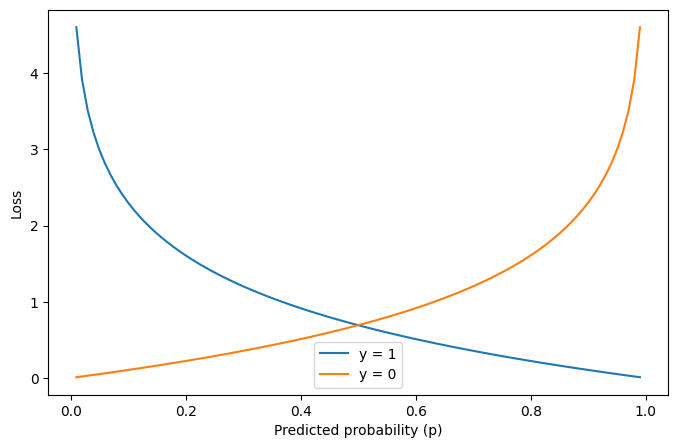

In [24]:
p = np.linspace(0.01, 0.99, 100)

plt.figure(figsize=(8, 5))
plt.plot(p, -np.log(p), label="y = 1")
plt.plot(p, -np.log(1 - p), label="y = 0")
plt.xlabel("Predicted probability (p)")
plt.ylabel("Loss")
plt.legend()

### Fitting a Logistic Regression Model


In [ ]:
from sklearn.linear_model import LogisticRegression


In [26]:
X_bal = df_train[["balance"]]

model_bal = LogisticRegression(penalty=None)

# not accessible
# model_bal.coef_

In [27]:
model_bal.fit(X_bal, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [28]:
model_bal.coef_

array([[0.00542776]])

In [29]:
model_bal.intercept_

array([-10.57621692])

Now we can extract predictions from our model. Let's do that for the training data.

In [30]:
model_bal.predict(X_bal)

array([0, 0, 0, ..., 0, 0, 0], shape=(6000,))

In [31]:
model_bal.predict_proba(X_bal)

array([[9.71103878e-01, 2.88961224e-02],
       [9.99753925e-01, 2.46075468e-04],
       [7.93461219e-01, 2.06538781e-01],
       ...,
       [9.97678348e-01, 2.32165227e-03],
       [9.87225795e-01, 1.27742051e-02],
       [9.68931081e-01, 3.10689192e-02]], shape=(6000, 2))

In [32]:
y_pred_proba = model_bal.predict_proba(X_bal)
y_pred_proba

array([[9.71103878e-01, 2.88961224e-02],
       [9.99753925e-01, 2.46075468e-04],
       [7.93461219e-01, 2.06538781e-01],
       ...,
       [9.97678348e-01, 2.32165227e-03],
       [9.87225795e-01, 1.27742051e-02],
       [9.68931081e-01, 3.10689192e-02]], shape=(6000, 2))

`predict_proba` gives probabilities for every class. We have two classes - therefore two probabilities. These probabilities add up to 1. 

Since it's a binary problem, we usually care about the probability of the positive class P(default=1). Let's use just that probability.


In [33]:
y_pred_proba = y_pred_proba[:, 1]
y_pred_proba

array([0.02889612, 0.00024608, 0.20653878, ..., 0.00232165, 0.01277421,
       0.03106892], shape=(6000,))

In [34]:
df_train["pred_proba"] = y_pred_proba
df_train.sample(10)

,default,student,balance,income,pred_proba
1982,0,1,718.211754,18788.748122,0.001257
2364,0,0,1546.760526,32928.636126,0.101491
2645,0,1,1021.370111,19032.509011,0.006480
3709,0,1,747.821683,19330.308404,0.001476
5718,0,1,219.728619,18401.982416,0.000084
4657,0,0,903.615716,20444.424123,0.003431
2292,0,1,963.201199,15938.066097,0.004734
1434,0,0,355.359646,65798.920034,0.000176
5352,0,0,405.273981,52571.184128,0.000230
3119,0,0,1112.348992,33468.822185,0.010575


Currently our predictions are floats between 0 and 1 - predicted probabilities. However, for many of the ways we will evaluate our classification models, we need binary predictions. 

In other words, we should apply some sort of a threshold to these probabilities.

In [35]:
y_pred = y_pred_proba > 0.5
y_pred

array([False, False, False, ..., False, False, False], shape=(6000,))

Let's plot the predicted probability against `balance`.

<Axes: xlabel='balance', ylabel='default'>

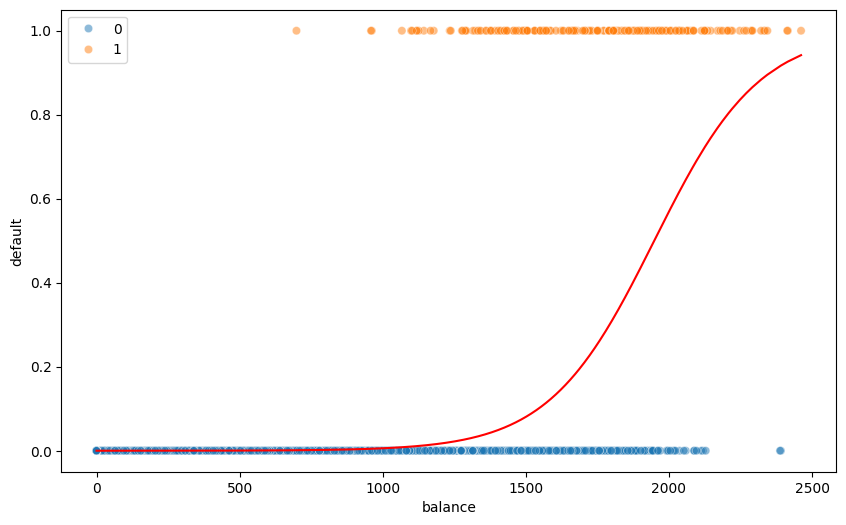

In [36]:
# Create figure
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_train, x="balance", y="default", hue="default", alpha=0.5)
sns.lineplot(x=X_bal["balance"], y=y_pred_proba, color="red")

Now how should we evaluate if our model is any good? Log loss is a metric we can use during training, but it's a metric that is difficult to interpret. For that we have various classification metrics.

The most basic of such metrics is accuracy - what is the proportion of predictions that match the true labels?


In [37]:
np.mean(y_pred == y_train)

np.float64(0.9736666666666667)

### Task - compare against "always 0" model

Is this a good model? What would the accuracy be if our model always predicted 0?

Calculate the accuracy of a "model" that always predicts 0.


In [38]:
np.mean(y_train == 0)

np.float64(0.968)

our model is just a tiny bit better than a model that always predicts 0!

The problem is not in our model, but in the metric. Since our dataset contains severe class imbalance, accuracy is not an adequate metric. Let's look into two more metrics that will help us reason about the performance of our model.

### Task - recall

Calculate recall. Recall - of all positive cases (cases that are actually default=1), what is the share that our model identified?


In [39]:
# Hint
# You will need these operations:
y_train == 1
(y_pred == 1) & (y_train == 1)
np.sum

<function sum at 0x112a321f0>

In [40]:
# recall - what proportion of positive cases does our model recall?
actual_positives = np.sum(y_train == 1)
true_positives = np.sum((y_pred == 1) & (y_train == 1))
true_positives / actual_positives


np.float64(0.2916666666666667)

### Task - precision

Calculate precision. Precision - of all positive predictions (model predicts default=1), what share is actually positive?


In [41]:
# precision - of all predicted positive cases, how many are actually positive?
pred_positives = np.sum(y_pred == 1)
true_positives = np.sum((y_pred == 1) & (y_train == 1))
true_positives / pred_positives

np.float64(0.717948717948718)

Our model currently is not very useful, because it only identifies 30% of the defaults at a threshold of 0.5.


By the way, we don't have to remember the formulas for precision, recall and accuracy (or for any of the metrics we will look into). scikit-learn provides functions for them.

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

print("Accuracy: ", accuracy_score(y_train, y_pred))
print("Recall: ", recall_score(y_train, y_pred))
print("Precision: ", precision_score(y_train, y_pred))


Accuracy:  0.9736666666666667
Recall:  0.2916666666666667
Precision:  0.717948717948718


### Task

- Fit a logistic regression model with two predictors - `balance` and `income`. 
- Make predictions on both the training and validation data.
- Report precision, recall and accuracy of the model for both prediction and training datasets. Use a threshold of 0.5.


In [ ]:
X_train_bal_inc = df_train[["balance", "income"]]
X_val_bal_inc = df_val[["balance", "income"]]
y_val = df_val["default"]

logreg_bal_inc = LogisticRegression()
logreg_bal_inc.fit(X_train_bal_inc, y_train)

y_train_pred = logreg_bal_inc.predict(X_train_bal_inc)
y_val_pred = logreg_bal_inc.predict(X_val_bal_inc)

print("Train precision:", precision_score(y_train, y_train_pred))
print("Val precision:  ", precision_score(y_val, y_val_pred))
print("Train recall:   ", recall_score(y_train, y_train_pred))
print("Val recall:     ", recall_score(y_val, y_val_pred))
print("Train accuracy: ", accuracy_score(y_train, y_train_pred))
print("Val accuracy:   ", accuracy_score(y_val, y_val_pred))


Train precision: 0.7411764705882353
Val precision:   0.7083333333333334
Train recall:    0.328125
Val recall:      0.22077922077922077
Train accuracy:  0.9748333333333333
Val accuracy:    0.9665


## Polynomial Features

Now let's add polynomial features to our model. The process is the same as with linear regression. What polynomial features allow us to do, as we will see later, is fit a nonlinear decision boundary.

In [59]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
poly = PolynomialFeatures(degree=4, include_bias=False)
X_train_poly = poly.fit_transform(X_train_bal_inc)

# Fit logistic regression with polynomial features
model_poly = LogisticRegression()
model_poly.fit(X_train_poly, y_train)

# Get predictions
y_pred = model_poly.predict(X_train_poly)


/Users/haroldasmackevicius/personal/ism/ism-data-science-2026/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


We have an issue - Logistic Regression training procedure fails to converge. This happens because we have large numbers in the data after applying a polynomial transformation.

What we need to do is scale the features down. There are two popular scaling approaches:
- standard scaling - subtract the mean and divide by standard deviation (z-scores)
- minmax scaling - subtract minimum and divide by the range in the data

In [45]:
balance = df_train["balance"]
balance_ss = (balance - balance.mean()) / balance.std()
balance_mm = (balance - balance.min()) / (balance.max() - balance.min())


<Axes: title={'center': 'balance minmax scaled'}, ylabel='Frequency'>

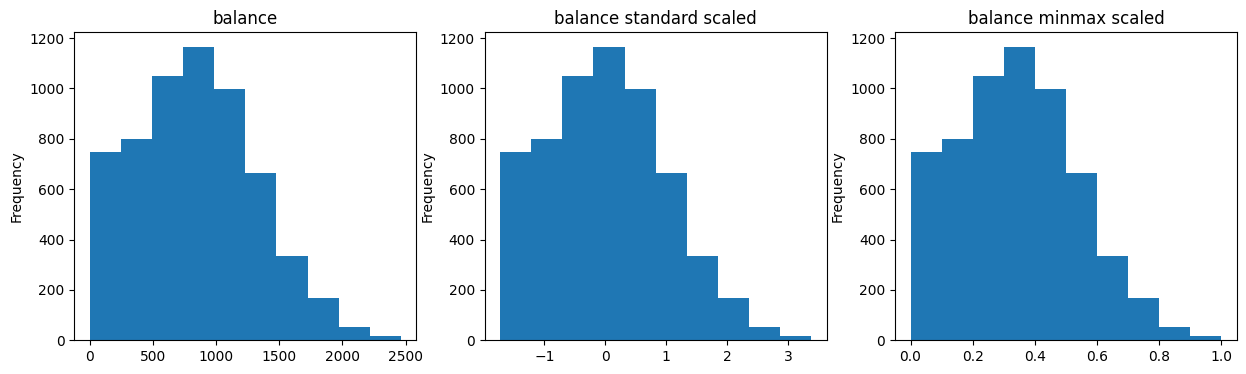

In [46]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
balance.plot.hist(ax=axs[0], title="balance")
balance_ss.plot.hist(ax=axs[1], title="balance standard scaled")
balance_mm.plot.hist(ax=axs[2], title="balance minmax scaled")


Using the standard or minmax scaling ensures that all our features have the same scale or range. This happens to improve the training procedure. It's also useful in other cases, such as when we use regularization, a topic which we'll go into next week.


In [47]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()


In [48]:
standard_scaler.fit_transform(X_train_bal_inc)


array([[ 9.72253112e-01,  6.69366374e-01],
       [-8.59822185e-01,  1.08233573e+00],
       [ 1.80092989e+00, -9.43955403e-01],
       ...,
       [-1.47058812e-03,  4.14939380e-01],
       [ 6.54071041e-01, -1.11701933e-01],
       [ 1.00081058e+00, -2.56671623e-01]], shape=(6000, 2))

In [49]:
# (X - min(x)) / (max(x) - min(x))
minmax_scaler.fit_transform(X_train_bal_inc)


array([[0.52853605, 0.57324387],
       [0.16964901, 0.64938404],
       [0.69086636, 0.27579179],
       ...,
       [0.33779235, 0.52633454],
       [0.46620705, 0.4292364 ],
       [0.5341302 , 0.40250798]], shape=(6000, 2))

Ok, so now I want to apply scaling and polynomial transformations to the training data. One approach is to create an object for each of the transformations separately, and then do fit_transform on the training features for each.

In [56]:
poly2 = PolynomialFeatures(degree=4, include_bias=False)
standard_scaler = StandardScaler()

X_train_poly = poly2.fit_transform(X_train_bal_inc)
X_train_scaled = standard_scaler.fit_transform(X_train_poly)
model_poly = LogisticRegression(penalty=None)
model_poly.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

But this is a lot of work as well as quite difficult to read. Luckily, scikit-learn provides an easier way to chain these operations via [Pipelines](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html).


In [57]:
from sklearn.pipeline import Pipeline

model_pipe = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=4, include_bias=False)),
        ("scaler", StandardScaler()),
        ("logistic", LogisticRegression(penalty=None)),
    ]
)

model_pipe.fit(X_train_bal_inc, y_train)
y_pred = model_pipe.predict(X_val_bal_inc)

print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Recall:   ", recall_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))


Accuracy:  0.9665
Recall:    0.22077922077922077
Precision: 0.7083333333333334


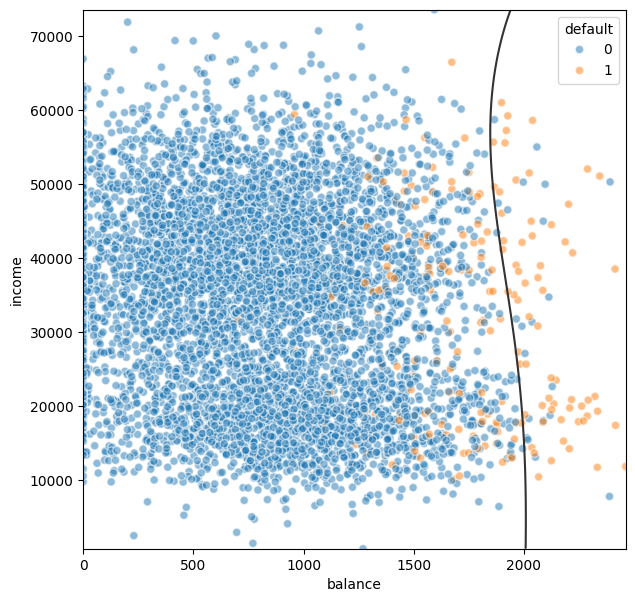

In [58]:
plot_decision_boundary(X_train_bal_inc["balance"], X_train_bal_inc["income"], y_train, model_pipe)


What if we want to apply transformations to some features but not others when using `Pipeline`? We have `ColumnTransformer` for that.

In [162]:
from sklearn.compose import ColumnTransformer

poly_scale = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[("poly_scale", poly_scale, ["balance"])],
    remainder="passthrough",
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("logistic", LogisticRegression(penalty=None)),
])

model.fit(X_train_bal_inc, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('poly_scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

## Dealing with class imbalance


Our dataset has what's called class imbalance - one of the classes, in this case the negative class (no default) dominates. This creates problems because it makes it difficult for the model to learn to predict accurately cases where default happened.



First let's begin by asking what kind of metric we could use here. There's one useful metric that we can use when we have an imbalanced dataset - F1 Score.

In [163]:
precision = 0.9
recall = 0.1
print("f1: ", 2 * (precision * recall) / (precision + recall))


f1:  0.18000000000000002


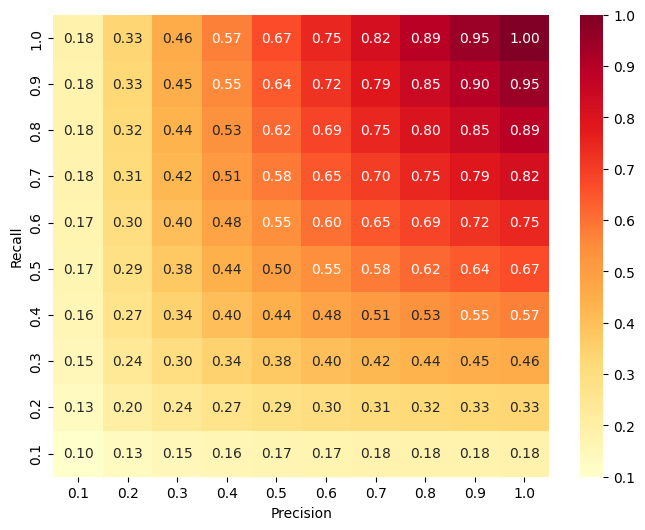

In [164]:
values = np.arange(0.1, 1.1, 0.1)
precision_grid, recall_grid = np.meshgrid(values, values)
f1_grid = 2 * (precision_grid * recall_grid) / (precision_grid + recall_grid)

plt.figure(figsize=(8, 6))
sns.heatmap(
    f1_grid,
    xticklabels=np.round(values, 1),
    yticklabels=np.round(values, 1),
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
)
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.gca().invert_yaxis()


The confusion matrix is also a useful tool for inspecting model performance. It's constructed by entering counts into the following table:


|  | **Predicted 0** | **Predicted 1** |
|---|---|---|
| **Actual 0** | True Negative (TN) | False Positive (FP) |
| **Actual 1** | False Negative (FN) | True Positive (TP) |



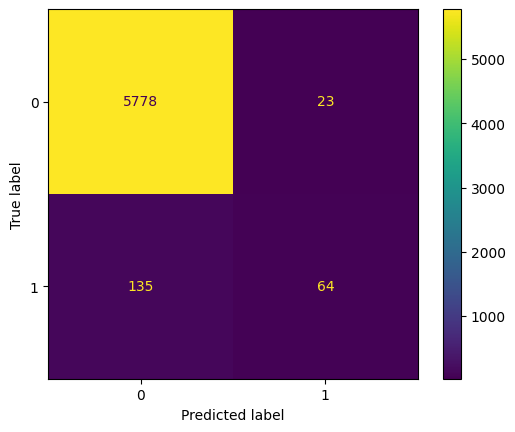

In [165]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model_pipe, X_train_bal_inc, y_train)


All of the metrics we discussed so far actually derive from the confusion matrix.

### Task

Go back to the definitions of the following classification metrics and  terms of the confusion matrix (TN, FP, FN, TP).
- accuracy
- precision
- recall

You do not need to write it in Python, just write down the formulas.

* accuracy = (TP + TN) / (TP + TN + FP + FN)
* precision = TP / (TP + FP)
* recall = TP / (TP + FN)

### Downsampling

We have lots of techniques available when it comes to addressing class imbalance. First and easiest one is downsampling.

Downsampling is simply taking a sample of the majority class, usually such that the share of classes is equal.


In [61]:
df_train["default"].value_counts()

default
0    5808
1     192
Name: count, dtype: int64

In [62]:
pos_cases = df_train[df_train["default"] == 1]
neg_cases = df_train[df_train["default"] == 0]

neg_cases_down = neg_cases.sample(pos_cases.shape[0])
df_train_down = pd.concat([pos_cases, neg_cases_down])

In [63]:
df_train_down["default"].value_counts()

default
1    192
0    192
Name: count, dtype: int64

In [64]:
y_train_down = df_train_down["default"]
X_train_bal_inc_down = df_train_down[["balance", "income"]]

logreg_bal_inc_down = LogisticRegression()
logreg_bal_inc_down.fit(X_train_bal_inc_down, y_train_down)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

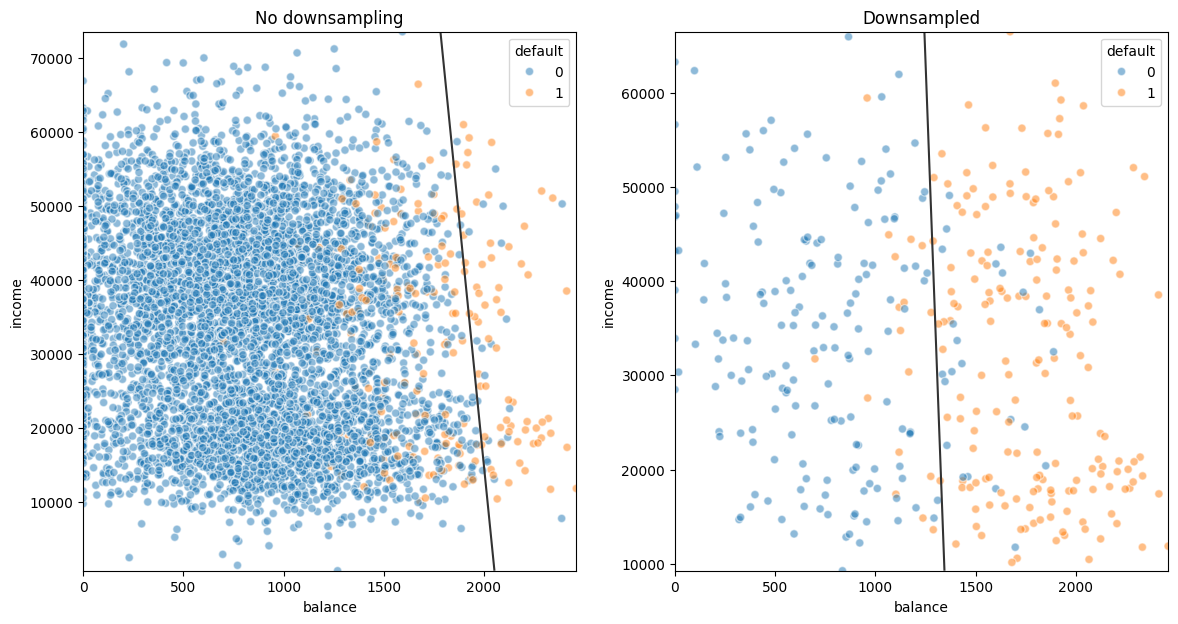

In [65]:
fig, axs = plt.subplots(1, 2, figsize=(14, 7))
plot_decision_boundary(
    df_train["balance"],
    df_train["income"],
    y_train,
    logreg_bal_inc,
    ax=axs[0],
    title="No downsampling",
)
plot_decision_boundary(
    df_train_down["balance"],
    df_train_down["income"],
    y_train,
    logreg_bal_inc_down,
    ax=axs[1],
    title="Downsampled",
)
plt.show()


### Oversampling

Another way to balance out the dataset is oversampling - creating new cases of the minority class. There are many ways to do this, ranging from as simple as randomly sampling from the minority class until classes balance out, to creating synthetic data.


In [171]:
pos_cases_up = pos_cases.sample(neg_cases.shape[0], replace=True)
df_train_up = pd.concat([pos_cases_up, neg_cases])

y_train_up = df_train_up["default"]
X_train_bal_inc_up = df_train_up[["balance", "income"]]
df_train_up.value_counts("default")

default
0    5801
1    5801
Name: count, dtype: int64

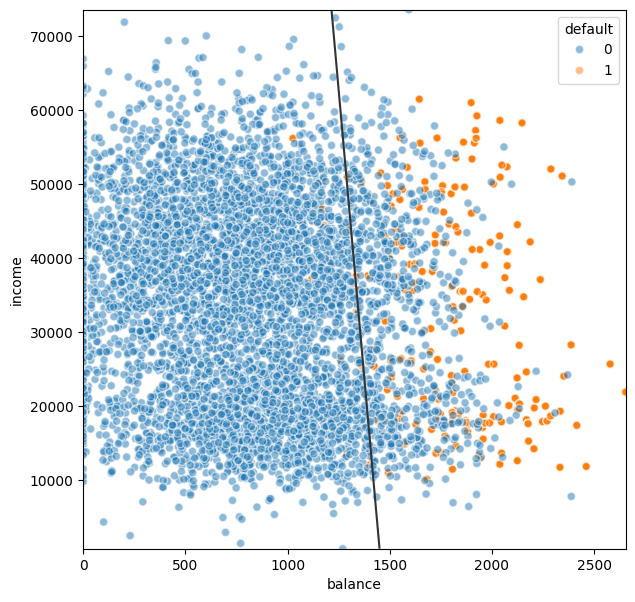

In [172]:
logreg_bal_inc_up = LogisticRegression()
logreg_bal_inc_up.fit(X_train_bal_inc_up, y_train_up)

plot_decision_boundary(
    X_train_bal_inc_up["balance"],
    X_train_bal_inc_up["income"],
    y_train_up,
    logreg_bal_inc_up,
)

plt.show()

Oversampling and downsampling both have disadvantages. With downsampling we're throwing away data we could train on. With oversampling we're duplicating existing minority samples, which can cause the model to memorize specific examples rather than learn general patterns. It's useful to be aware of these approaches, but there is a third, superior approach.

Important thing to note when dealing with class imbalance - unlike other transformations (scaling, polynomials), we should only apply undersampling or oversampling to the training data. By oversampling or undersampling, we change class distribution in our dataset, and in order to have a realistic measure of the performance of our model, it's key that the validation data and test data have come from the same distribution and that this distribution resembles the real world as closely as possible.


## Adjusting class weights

One effective strategy (if supported by the algorithm) is to adjust the weight of the minority class in the loss function. In logistic regression, which directly minimizes log loss, we can increase the penalty for misclassifying positive labels (the minority class) to improve model performance.

What is the optimal weight? The class_weight="balanced" setting weights each class inversely proportional to its frequency. In our case, since only ~3.3% of observations are defaults, the positive class gets roughly 30× more weight in the loss function — so misclassifying one default costs as much as misclassifying 30 non-defaults.


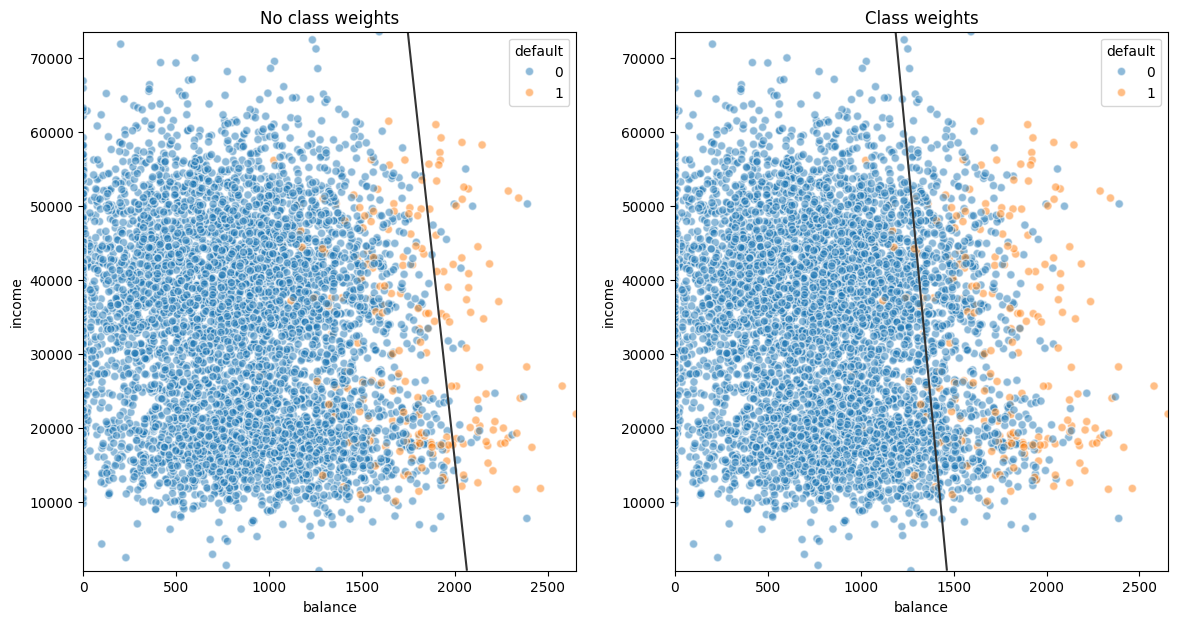

In [173]:
# Fit logistic regression with balanced class weights
logreg_bal_inc_weighted = LogisticRegression(class_weight="balanced")
logreg_bal_inc_weighted.fit(X_train_bal_inc, y_train)

fig, axs = plt.subplots(1, 2, figsize=(14, 7))
plot_decision_boundary(
    X_train_bal_inc["balance"],
    X_train_bal_inc["income"],
    y_train,
    logreg_bal_inc,
    ax=axs[0],
    title="No class weights",
)
plot_decision_boundary(
    X_train_bal_inc["balance"],
    X_train_bal_inc["income"],
    y_train,
    logreg_bal_inc_weighted,
    ax=axs[1],
    title="Class weights",
)
plt.show()

## Putting it all together

### Task

Fit a logistic regression model that predicts `default`, using all of the variables available in the dataset.

- Apply scaling and polynomial transformations, but only to `balance` and `income` features (we do not need to apply scaling to categorical columns). Use `ColumnTransformer`.
- Use the `class_weight` argument to address class imbalance.


In [174]:
# Hint
from sklearn.compose import ColumnTransformer

poly_scale = Pipeline([("poly", ...), ("scale", ...)])

preprocessor = ColumnTransformer(
    transformers=[("poly_scale", poly_scale, ["feat1", "feat2"])],
    remainder="passthrough",
)

model_final = Pipeline([("preprocessor", preprocessor), ("classifier", ...)])  # model

# Select features
# fit the model


In [175]:
from sklearn.compose import ColumnTransformer

poly_scale = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[("scale_poly", poly_scale, ["balance", "income"])],
    remainder="passthrough",
)

model_final = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(class_weight="balanced", penalty=None)),
    ]
)

X_train = df_train[["balance", "income", "student"]]
y_train = df_train["default"]

model_final.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale_poly', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Task - report the performance of the model with threshold 0.5

Use `model_final` from above to make predictions on the validation set.

Report recall, precision, accuracy and F1 score. Use a threshold of 0.5.



In [176]:
from sklearn.metrics import f1_score

X_val = df_val[["balance", "income", "student"]]
y_val = df_val["default"]
y_pred = model_final.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("F1 score:", f1_score(y_val, y_pred))


Accuracy: 0.8715
Recall: 0.9090909090909091
Precision: 0.19292604501607716
F1 score: 0.3183023872679045


### Task - report the performance of the model for various thresholds

Report recall, precision, accuracy and F1 score of the model we trained above *on the validation set* for a set of thresholds. Choose the most effective visualization. 

What threshold would you choose?


In [177]:
# hint
thresholds = np.arange(0.5, 1, 0.01)

# Make predictions on the validation set

metrics = []
for threshold in thresholds:
    # Apply threshold
    ...
    
    # calculate metrics and append to metrics list
    ...

metrics_df = pd.DataFrame(metrics)
# make plots


<Axes: xlabel='threshold', ylabel='recall'>

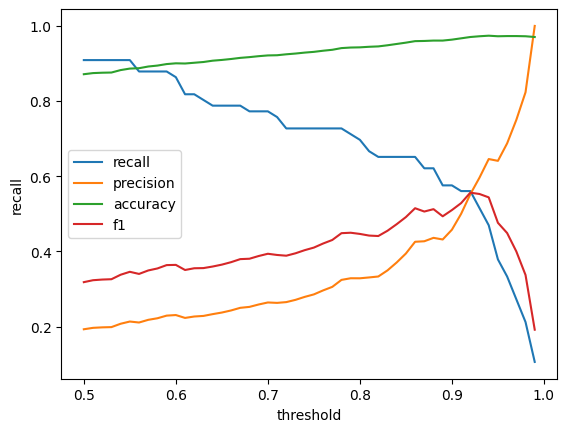

In [178]:
thresholds = np.arange(0.5, 1, 0.01)

X_val = df_val[["balance", "income", "student"]]
y_val = df_val["default"]
preds = model_final.predict_proba(X_val)[:, 1]

recall_scores = []
precision_scores = []
accuracy_scores = []
f1_scores = []

for threshold in thresholds:
    y_pred = preds > threshold
    recall_scores.append(recall_score(y_val, y_pred))
    precision_scores.append(precision_score(y_val, y_pred))
    accuracy_scores.append(accuracy_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred))

metrics_df = pd.DataFrame({
    "threshold": thresholds,
    "recall": recall_scores,
    "precision": precision_scores,
    "accuracy": accuracy_scores,
    "f1": f1_scores,
})

sns.lineplot(data=metrics_df, x="threshold", y="recall", label="recall")
sns.lineplot(data=metrics_df, x="threshold", y="precision", label="precision")
sns.lineplot(data=metrics_df, x="threshold", y="accuracy", label="accuracy")
sns.lineplot(data=metrics_df, x="threshold", y="f1", label="f1")


This is called threshold tuning. When we use downsampling, oversampling, or class weight adjustment, the model is trained on a different class distribution than the real world. As a result, the default 0.5 threshold may no longer be optimal, and we should search for a better one.


## k-Nearest Neighbors

There's another algorithm that is very simple and useful to be aware of, however not that popular nowadays.

<Axes: xlabel='balance', ylabel='income'>

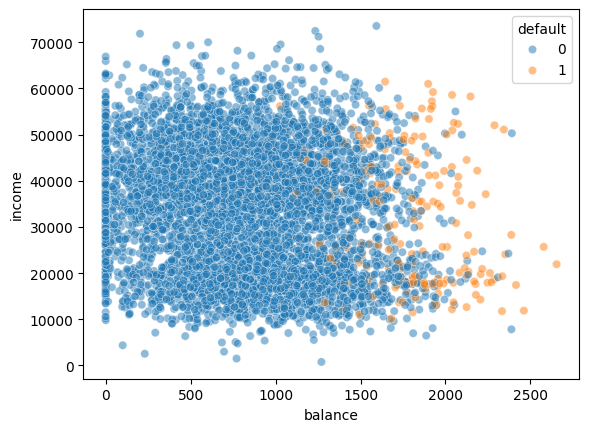

In [69]:
sns.scatterplot(
    data=df_train,
    x="balance",
    y="income",
    hue="default",
    alpha=0.5
)

In [70]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=10)
model_knn.fit(X_train_bal_inc_up, y_train_up)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Task

Train kNN classifiers for predicting `default` for n_neighbors values between 2 and 50. For training use the upsampled dataset `df_train_up`. Use all three features.

During each iteration, make predictions on the validation and the training data and save F1 scores for each into lists. Then, create a lineplot that shows how F1 score changes as a function of n_neighbors for validation and training data.


In [ ]:
# Range of k values to try
k_values = list(range(50, 1, -1))
train_f1 = []
val_f1 = []

# Select the necessary features

for k in k_values:
    # fit the model with n_neighbors=k
    ...
    # make predictions on X_train and X_val and store them in the lists
    ...

# Plot the results


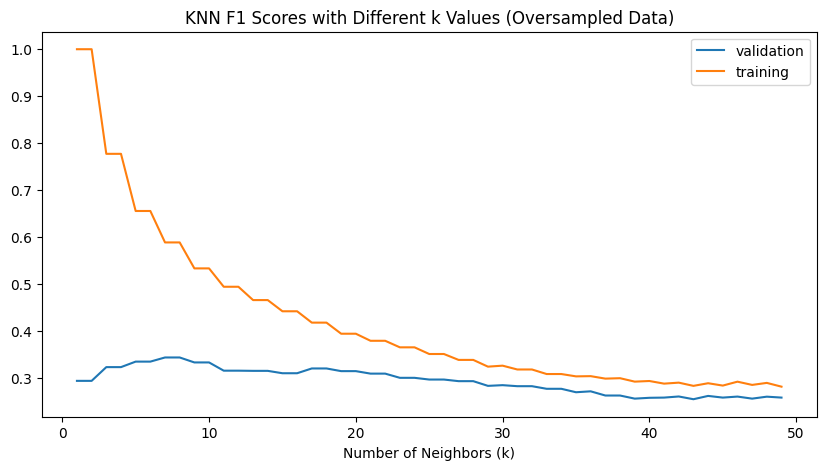

In [179]:
# Range of k values to try
k_values = list(range(1, 50))
train_f1 = []
val_f1 = []

X_train_up = df_train_up[["balance", "income", "student"]]
X_train = df_train[["balance", "income", "student"]]
X_val = df_val[["balance", "income", "student"]]
y_val = df_val["default"]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_up, y_train_up)

    y_train_pred = knn.predict(X_train)
    y_val_pred = knn.predict(X_val)

    train_f1.append(f1_score(y_train, y_train_pred))
    val_f1.append(f1_score(y_val, y_val_pred))

metrics_df = pd.DataFrame({
    'k': k_values,
    'validation': val_f1,
    'training': train_f1,
})

plt.figure(figsize=(10, 5))
sns.lineplot(data=metrics_df, x='k', y='validation', label='validation')
sns.lineplot(data=metrics_df, x='k', y='training', label='training')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('')
plt.title('KNN F1 Scores with Different k Values (Oversampled Data)')
plt.show()


What we are performing right now is called hyperparameter search or hyperparameter tuning. Hyperparameters are model attributes that determine how the model is fit. E.g. LogisticRegression hyperparameters are:
- `class_weight` - what weights should the loss function apply to the positive class?
- If we're using `PolynomialFeatures` in the pipeline, then `degree`


### Task - choose the best model and report its performance

From the task above, take the best model (n_neighbors=7), fit it again on the upsampled training data and report its performance on `df_test`. Report F1 score and plot the confusion matrix.


In [ ]:
# the best model is the one trained on oversampled training data with n_neighbors set to 7
X_test = df_test[["balance", "income", "student"]]
y_test = df_test["default"]

X_train_up = df_train_up[["balance", "income", "student"]]
y_train_up = df_train_up["default"]

knn_model = KNeighborsClassifier(n_neighbors=7)

knn_model.fit(X_train_up, y_train_up)
y_pred = knn_model.predict(X_test)

f1_score(y_test, y_pred)


0.3105022831050228

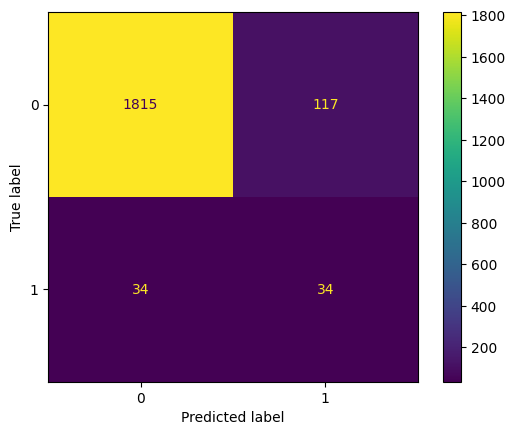

In [73]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(knn_model, X_test, y_test)


## Recap

- Before modelling, we usually split data into three datasets - train, validation and testing.
    - Training - for training the model (that's what we pass into .fit())
    - Validation - for finding the best model in terms of algorithm and hyperparameters.
    - Testing - for reporting the final results.
- Never refit your model on the validation or testing data.
- Most algorithms happen to work better on scaled features. For that we use StandardScaler and MinMaxScaler.
- In logistic regression, polynomial transformations allow for non-linearities in the decision boundary. However, we have to be careful about overfitting.
- We have three approaches when it comes to addressing class imbalance - oversampling, undersampling and adjusting class weights. Not all algorithms support adjusting class weights.
- There are numerous metrics that we can use to talk about model performance - accuracy, precision, recall, f1_score. All of these can be derived from the confusion matrix.
- To find the most optimal model, we tune model hyperparameters and test how the model performs on the validation set.
